## draw_storm_features.ipynb
Author: Robby M. Frost

Organization: OU Advanced Radar Research Center

Created: 27 May 2026

Purpose: Draw gust front and inflow/outflow partitions

In [1]:
import pyart
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib import rc
import sys
from mpl_point_clicker import clicker
from matplotlib.ticker import MultipleLocator
import os
import glob
from datetime import datetime, timedelta

from lidar_utils import *
sys.path.append('/home/robbyfrost/Analysis/TurbTor_Radar')
from functions import *

# plotting set up
plt.rcParams['axes.labelweight'] = 'normal'
plt.rcParams['text.latex.preamble'] = r'\usepackage{bm}'
rc('font', family='sans-serif')
rc('font', weight='normal', size=7.5)
rc('figure', facecolor='white')

%matplotlib ipympl

# path to cfradial data
dlid = "/data/arrcwx/robbyfrost/halo/20250425/cfrada/"
# path to storm attrs
dsa = "/data/arrcwx/robbyfrost/halo/20250425/storm_attr/"

# desired time
jt = 19
# circulation radius
crad = 4 # km

# list of lidar file paths
lfiles = sorted(glob.glob(f"{dlid}*"))
# read lidar file
ds = xr.open_dataset(lfiles[jt])

# extract arrays
vr = ds.vr.values
az = ds.azimuth.values
r = ds.range.values*1e3
vort = ((vr[2:,:]-vr[:-2,:]) / ((np.deg2rad(az[2:])-np.deg2rad(az[:-2]))[:,None])) / (r[None,:])
x, y = dis_angle_to_2Dxy(r, north0_to_arctheta(az))

# time information
tsstr = ds.attrs['time_coverage_start'][:10] + " " + ds.attrs['time_coverage_start'][11:19]
tsdt = datetime.strptime(tsstr, '%Y-%m-%d %H:%M:%S')
tstr = tsdt.strftime("%Y%m%d_%H%M%S")
testr = ds.attrs['time_coverage_end'][:10] + " " + ds.attrs['time_coverage_end'][11:19]
tedt = datetime.strptime(testr, '%Y-%m-%d %H:%M:%S')

# plotting dictionary
lidar_dict = {
    'x': x,
    'y': y,
    'vr': vr,
    'vort': vort,
    'tsstr': tsstr,
    'tsdt': tsdt,
    'elplt': np.nanmean(ds.elevation.values),
}

# read in vortex position
dvortex = f"{dsa}vortex_{tstr}_0.50el.txt"
vortex = np.loadtxt(dvortex, skiprows=1, delimiter=',')
xv, yv = vortex[0], vortex[1]

# Mask points inside circle
dist = np.sqrt((x/1e3 - xv)**2 + (y/1e3 - yv)**2)
inside_circle = dist <= crad


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



# Vortex position

In [ ]:
# # make fig
# fig, ax = plot_ppi_vr(lidar_dict)

# # locate vortex
# klicker = clicker(ax, ["vortex"], markers=["o"], colors='black')
# plt.show()

In [ ]:
# # close figure
# plt.close(fig)
# # extract coordinates
# coords = klicker.get_positions()['vortex']
# lx, ly = coords[:,0], coords[:,1]

# # output path
# outdir = f"{dsa}vortex_{tstr}_{lidar_dict['elplt']:.2f}el.txt"
# # output text file
# np.savetxt(
#     outdir, 
#     np.column_stack([lx,ly]), 
#     delimiter=',', 
#     header='X positions [km], Y positions [km]', 
#     comments=''
# )
# print(f"Vortex coordinates saved to: {outdir}")

# Inflow/outflow split circle

### This is used to identify a constant radius around the mesocyclone over time and to split the circle into inflow and outflow regions.

# Draw gust front
### (North to south)

In [ ]:
# set plot limits
lidar_dict['xlims'] = [xv-(crad+0.5), xv+(crad+0.5)]
lidar_dict['ylims'] = [yv-(crad+0.5), yv+(crad+0.5)]

# make fig
fig, ax = plot_ppi_vr(lidar_dict)
# show circle
cfield = inside_circle.astype(int)
ax.contour(lidar_dict['x'].T/1e3,
           lidar_dict['y'].T/1e3,
           cfield.T,
           levels=[0.5],
           colors='blue',
           alpha=1)

# draw bounds
klicker = clicker(ax, ["gf"], markers=["o"], colors='black')
plt.show()

In [ ]:
# close figure
plt.close(fig)
# extract coordinates
coords = klicker.get_positions()['gf']
lx, ly = coords[:,0], coords[:,1]

# output path
outdir = f"{dsa}gf_{tstr}_{lidar_dict['elplt']:.2f}el.txt"
# output text file
np.savetxt(
    outdir,
    np.column_stack([lx,ly]), 
    delimiter=',', 
    header='X positions [km], Y positions [km]', 
    comments=''
)
print(f"Full GF coordinates saved to: {outdir}")

In [ ]:
gf_coords = np.loadtxt(
    f"{dsa}gf_{tstr}_{lidar_dict['elplt']:.2f}el.txt",
    delimiter=',', 
    skiprows=1
)
gfx, gfy = gf_coords[:,0], gf_coords[:,1]

# Outline inflow side of circle
### (South to north)

In [ ]:
# set plot limits
lidar_dict['xlims'] = [xv-(crad+2), xv+(crad+2)]
lidar_dict['ylims'] = [yv-(crad+2), yv+(crad+2)]

# make fig
fig, ax = plot_ppi_vr(lidar_dict)
# show circle
cfield = inside_circle.astype(int)
ax.contourf(lidar_dict['x']/1e3, 
            lidar_dict['y']/1e3,
            cfield,
            levels=[0.5,1.5],
            colors='black',
            alpha=0.5)
# plot gust front
ax.plot(gf_coords[:,0], 
        gf_coords[:,1],
        c='black', 
        lw=3)

# draw bounds
klicker = clicker(ax, ["inf"], markers=["o"], colors='black')
plt.show()

In [ ]:
# close figure
plt.close(fig)

# extract coordinates
coords = klicker.get_positions()['inf']
# add inflow bounds to gust front line
coords = np.concatenate([gf_coords, coords])
# close polygon
if not np.array_equal(coords[0], coords[-1]):
    coords = np.vstack([coords, coords[0]])
lx, ly = coords[:,0], coords[:,1]

# output path
outdir = f"{dsa}circ_inflow_bounds_{tstr}_{lidar_dict['elplt']:.2f}el.txt"
# output text file
np.savetxt(
    outdir,
    np.column_stack([lx,ly]), 
    delimiter=',', 
    header='X positions [km], Y positions [km]', 
    comments=''
)
print(f"Circle inflow bounds saved to: {outdir}")

# Outline outflow side of circle
### (South to north)

In [ ]:
# set plot limits
lidar_dict['xlims'] = [xv-(crad+2), xv+(crad+2)]
lidar_dict['ylims'] = [yv-(crad+2), yv+(crad+2)]

# make fig
fig, ax = plot_ppi_vr(lidar_dict)
# show circle
cfield = inside_circle.astype(int)
ax.contourf(lidar_dict['x']/1e3, 
            lidar_dict['y']/1e3,
            cfield,
            levels=[0.5,1.5],
            colors='black',
            alpha=0.5)
# plot gust front
ax.plot(gf_coords[:,0], 
        gf_coords[:,1],
        c='black', 
        lw=3)

# draw bounds
klicker = clicker(ax, ["out"], markers=["o"], colors='black')
plt.show()

In [ ]:
# close figure
plt.close(fig)

# extract coordinates
coords = klicker.get_positions()['out']
# add inflow bounds to gust front line
coords = np.concatenate([gf_coords, coords])
# close polygon
if not np.array_equal(coords[0], coords[-1]):
    coords = np.vstack([coords, coords[0]])
lx, ly = coords[:,0], coords[:,1]

# output path
outdir = f"{dsa}circ_outflow_bounds_{tstr}_{lidar_dict['elplt']:.2f}el.txt"
# output text file
np.savetxt(
    outdir,
    np.column_stack([lx,ly]), 
    delimiter=',', 
    header='X positions [km], Y positions [km]', 
    comments=''
)
print(f"Circle inflow bounds saved to: {outdir}")

# Plot all 3 masks

In [2]:
gf_coords = np.loadtxt(f"{dsa}gf_{tstr}_{lidar_dict['elplt']:.2f}el.txt",
                       delimiter=',', 
                       skiprows=1)
gfx, gfy = gf_coords[:,0], gf_coords[:,1]
inf = np.loadtxt(f"{dsa}circ_inflow_bounds_{tstr}_{lidar_dict['elplt']:.2f}el.txt",
                 delimiter=',', 
                 skiprows=1)
out = np.loadtxt(f"{dsa}circ_outflow_bounds_{tstr}_{lidar_dict['elplt']:.2f}el.txt",
                 delimiter=',', 
                 skiprows=1)

gf_mask = mask_around_bendy_line(lidar_dict['x']/1e3, 
                                 lidar_dict['y']/1e3, 
                                 gfx, 
                                 gfy, 
                                 des_dist=0.5)
inflow_mask = mask_inside(lidar_dict['x']/1e3,
                          lidar_dict['y']/1e3,
                          inf[:,0],
                          inf[:,1],
                          grid_2d=True)
outflow_mask = mask_inside(lidar_dict['x']/1e3,
                           lidar_dict['y']/1e3,
                           out[:,0],
                           out[:,1],
                           grid_2d=True)

full_inf_mask = inflow_mask & inside_circle & ~gf_mask
full_out_mask = outflow_mask & inside_circle & ~gf_mask
full_gf_mask = gf_mask & inside_circle

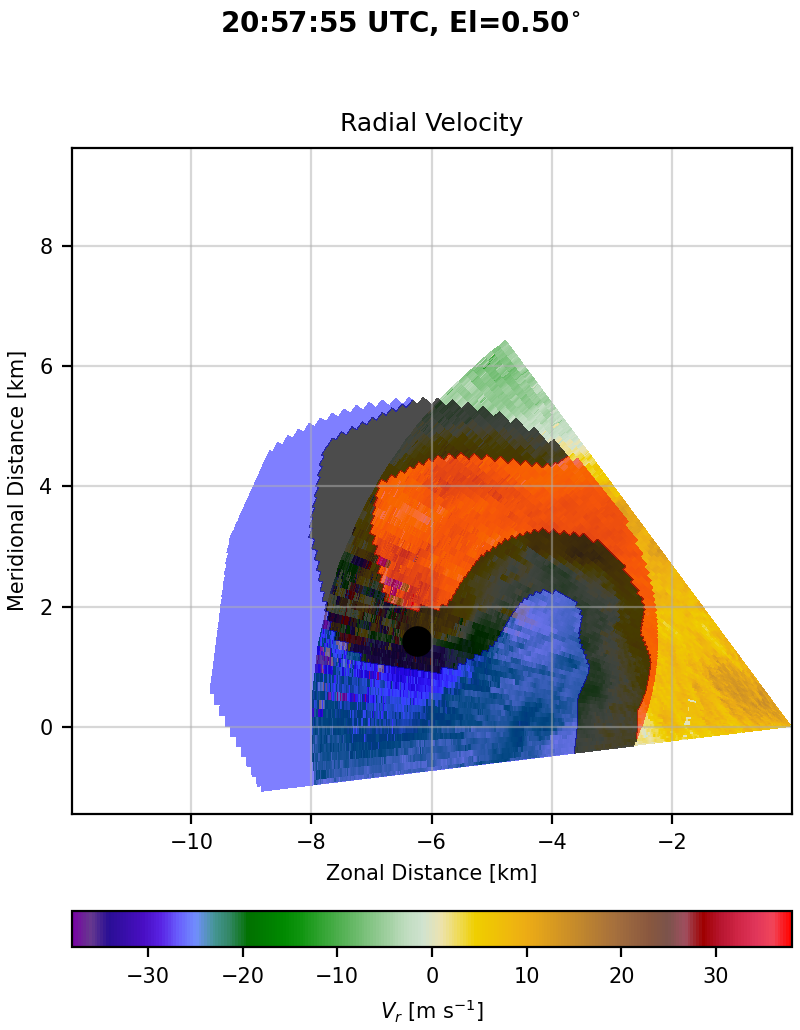

In [3]:
# make figure
xlims = [xv-5, xv+5]
ylims = [yv-5, yv+5]
fig, ax = plot_ppi_vr(lidar_dict)

# plot gust front mask
ax.contourf(lidar_dict['x']/1e3, 
            lidar_dict['y']/1e3,
             full_gf_mask,
             levels=[0.5,1.5],
             colors='black',
             alpha=0.7)
# plot inflow mask
ax.contourf(lidar_dict['x']/1e3, 
            lidar_dict['y']/1e3,
            full_inf_mask,
            levels=[0.5,1.5],
            colors='red',
            alpha=0.5)
# plot outflow mask
ax.contourf(lidar_dict['x']/1e3, 
            lidar_dict['y']/1e3,
            full_out_mask,
            levels=[0.5,1.5],
            colors='blue',
            alpha=0.5)


ax.scatter(xv, 
           yv,
           s=100, 
           c='black')

# Second gust front

In [ ]:
xlims = [xv-(crad+2), xv+(crad+2)]
ylims = [yv-(crad+2), yv+(crad+2)]
# make fig
if mode == 0:
    fig, axs = plot_dda(ds, oupr_dict, jz, xlims, ylims, bspacing=2)
    # show circle
    cfield = inside_circle.astype(int)
    axs.contour(ds.x/1e3, ds.y/1e3, 
                cfield,
                levels=[0.5],
                colors='blue',
                alpha=1)
    # draw bounds
    klicker = clicker(axs, ["gf"], markers=["o"], colors='black')
    plt.show()

In [ ]:
plt.close(fig)
gf_coords = klicker.get_positions()['gf']
rx, ry = gf_coords[:,0], gf_coords[:,1]

if mode == 0:
    outdir = f"{dsa}gf2_{tstring}_{el:.2f}el.txt"
    np.savetxt(outdir, np.column_stack([rx,ry]), delimiter=',', header='X positions [km], Y positions [km]', comments='')
    print(f"Full GF coordinates saved to: {outdir}")

# Circle worm

In [ ]:
xlims = [xv-4, xv+8]
ylims = [yv-6, yv+6]
fig, axs = plot_ppi(oupr_dict, 0, xlims, ylims)

# draw bounds
klicker = clicker(axs, ["worm"], markers=["+"], colors='black')
plt.show()

In [ ]:
plt.close(fig)
poly_coords = klicker.get_positions()['worm']

if not np.array_equal(poly_coords[0], poly_coords[-1]):
    poly_coords = np.vstack([poly_coords, poly_coords[0]])
px, py = poly_coords[:,0], poly_coords[:,1]

outdir = f"{dsa}worm_{tstring}.txt"
np.savetxt(outdir, np.column_stack([px,py]), delimiter=',', header='X positions [km], Y positions [km]', comments='')
print(f"Full GF coordinates saved to: {outdir}")

# Inflow bounds

In [ ]:
xlims = [xv-10, xv+20]
ylims = [yv-20, yv+10]

if mode == 0:
    fig, axs = plot_dda(ds, 0, xlims, ylims, bspacing=10)
    # plot vortex
    axs.plot(xv, yv, 'rv', markersize=10, label='Vortex')
    # draw bounds
    klicker = clicker(axs, ["inf_bounds"], markers=["o"], colors='black')
    plt.show()

if mode == 1:
    fig, axs = plot_ppi_barnes(ds, lev, xlims, ylims)
    # plot vortex
    for ax in axs:
        ax.plot(xv, yv, 'rv', markersize=10, label='Vortex')
    # draw bounds
    klicker = clicker(axs[1], ["inf_bounds"], markers=["o"], colors='black')
    plt.show()

In [ ]:
plt.close(fig)
poly_coords = klicker.get_positions()['inf_bounds']

if not np.array_equal(poly_coords[0], poly_coords[-1]):
    poly_coords = np.vstack([poly_coords, poly_coords[0]])

px, py = poly_coords[:,0], poly_coords[:,1]

if mode == 0:
    outdir = f"{dsa}inflow_bounds_{tstring}.txt"
    np.savetxt(outdir, np.column_stack([px,py]), delimiter=',', header='X positions [km], Y positions [km]', comments='')
    print(f"Inflow bounds saved to: {outdir}")
if mode == 1:
    outdir = f"{dsa}inflow_bounds_{tstring}.txt"
    np.savetxt(outdir, np.column_stack([px,py]), delimiter=',', header='X positions [km], Y positions [km]', comments='')
    print(f"Inflow bounds saved to: {outdir}")

# RFD bounds

In [ ]:
xlims = [xv-15, xv+15]
ylims = [yv-15, yv+15]

if mode == 0:
    fig, axs = plot_dda(ds, 0, xlims, ylims, bspacing=10)
    # plot vortex
    axs.plot(xv, yv, 'rv', markersize=10, label='Vortex')
    # draw bounds
    klicker = clicker(axs, ["rfd_bounds"], markers=["o"], colors='black')
    plt.show()

if mode == 1:
    fig, axs = plot_ppi_barnes(ds, lev, xlims, ylims)
    # plot vortex
    for ax in axs:
        ax.plot(xv, yv, 'rv', markersize=10, label='Vortex')
    # draw bounds
    klicker = clicker(axs[1], ["rfd_bounds"], markers=["o"], colors='black')
    plt.show()

In [ ]:
plt.close(fig)
poly_coords = klicker.get_positions()['rfd_bounds']

if not np.array_equal(poly_coords[0], poly_coords[-1]):
    poly_coords = np.vstack([poly_coords, poly_coords[0]])

px, py = poly_coords[:,0], poly_coords[:,1]

if mode == 0:
    outdir = f"{dsa}rfd_bounds_{tstring}.txt"
    np.savetxt(outdir, np.column_stack([px,py]), delimiter=',', header='X positions [km], Y positions [km]', comments='')
    print(f"RFD bounds saved to: {outdir}")
if mode == 1:
    outdir = f"{dsa}rfd_bounds_{tstring}.txt"
    np.savetxt(outdir, np.column_stack([px,py]), delimiter=',', header='X positions [km], Y positions [km]', comments='')
    print(f"RFD bounds saved to: {outdir}")